In [135]:
import numpy as np
import dill as pk

from utils.optical_loading import pwv_interp
from utils.parsing import parse_dict, parse_neps
from astropy.time import Time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pwv = pwv_interp()


with open("backups/nets_111925.pk", "rb") as f:
    net_dict = pk.load(f)


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
df = parse_dict(net_dict=net_dict)

<Axes: xlabel='neps', ylabel='labels'>

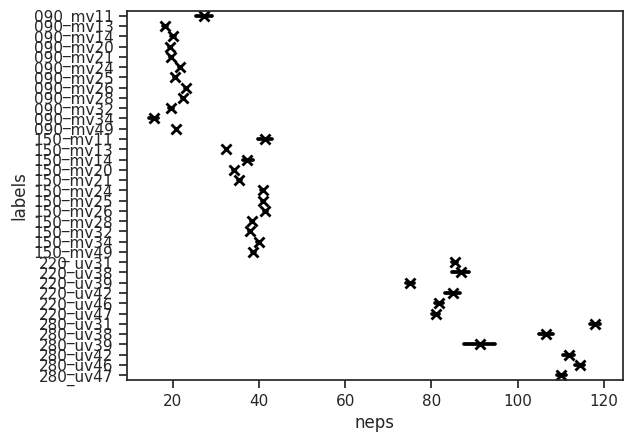

In [137]:
t_cut_low = Time("2025-03-05T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-05-03T00:00:00", format="isot", scale="utc")
sns.pointplot(
    data=df.where(
        (1.1 < df.pwv / np.sin(np.deg2rad(df.el)))
        & (df.pwv / np.sin(np.deg2rad(df.el)) < 1.5)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
    ),
    x="neps",
    y="labels",
    linestyle="none",
    marker="x",
    color="black",
    zorder=2,
)

In [138]:
nep_df = parse_neps(net_dict=net_dict)

/so/home/jorlo/dev/LAT_analysis/utils/parsing.py:143: RuntimeWarning: invalid value encountered in scalar divide
  neis.append(nep/cur_phicals[j][i] * 9e6/(2 * np.pi))


In [112]:
neps = nep_df.neps.to_numpy()
nep_labels = nep_df.labels.to_numpy(dtype=str)

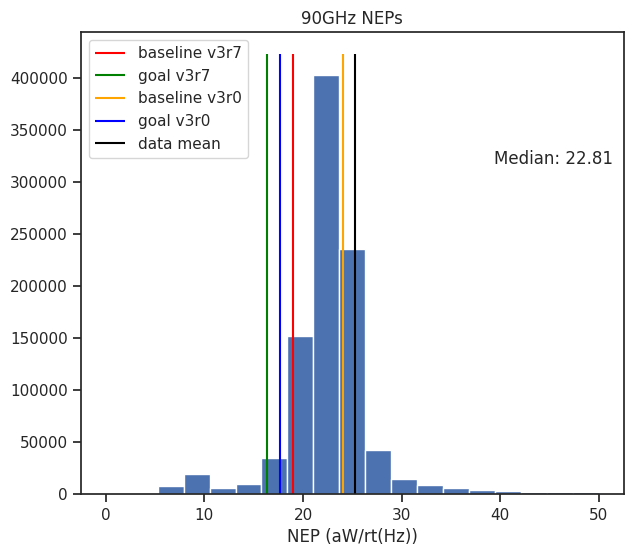

In [113]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(
    (np.char.find(nep_labels, "090") != -1)
    & (neps > 1e-6)
    & (1.1 < nep_df.pwv / np.sin(np.deg2rad(nep_df.el)))
    & (nep_df.pwv / np.sin(np.deg2rad(nep_df.el)) < 1.5)
)[0]

baseline_r0 = 24.04
baseline_r7 = 18.99

goal_r0 = 17.70
goal_r7 = 16.37

plt.hist(neps[flags] * 1e6, bins=np.linspace(0, 50, 20))
# plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags] * 1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("90GHz NEPs")
plt.legend()

plt.text(
    0.75 * xmin, 0.75 * ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags] * 1e6))
)

f.savefig("./plts/neps/neps_090.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/neps/neps_090.png", dpi=600, bbox_inches="tight")

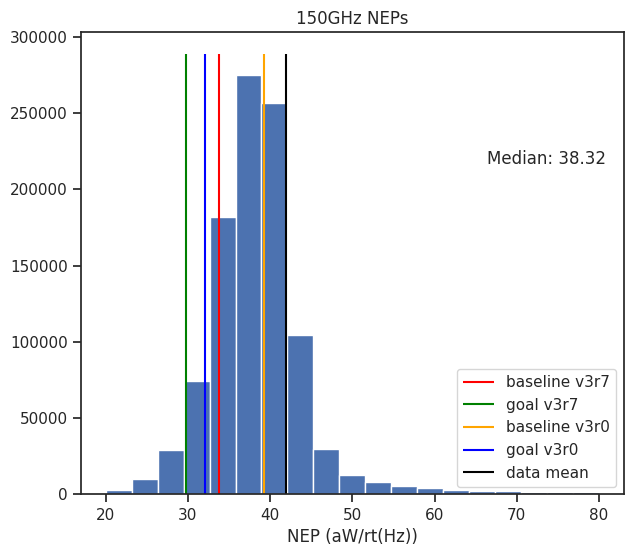

In [114]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(
    (np.char.find(nep_labels, "150") != -1)
    & (neps > 1e-6)
    & (1.1 < nep_df.pwv / np.sin(np.deg2rad(nep_df.el)))
    & (nep_df.pwv / np.sin(np.deg2rad(nep_df.el)) < 1.5)
)[0]

baseline_r0 = 39.25
baseline_r7 = 33.81

goal_r0 = 32.13
goal_r7 = 29.72

plt.hist(neps[flags] * 1e6, bins=np.linspace(20, 80, 20))
# plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags] * 1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("150GHz NEPs")
plt.legend()

plt.text(
    0.8 * xmin, 0.75 * ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags] * 1e6))
)

f.savefig("./plts/neps/neps_150.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/neps/neps_150.png", dpi=600, bbox_inches="tight")

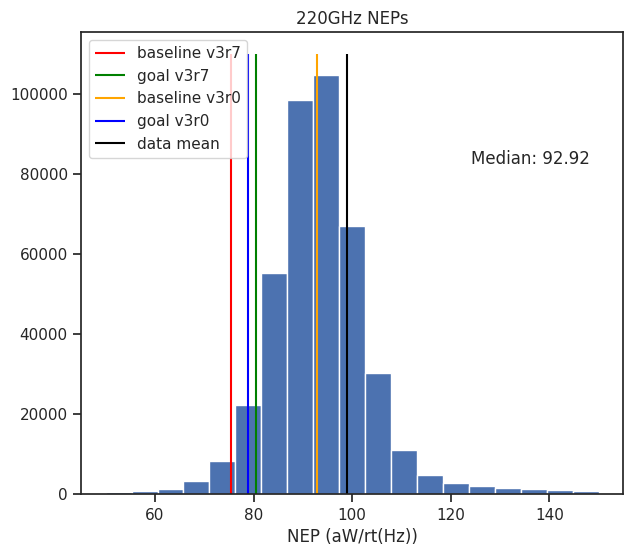

In [115]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(
    (np.char.find(nep_labels, "220") != -1)
    & (neps > 1e-6)
    & (1.1 < nep_df.pwv / np.sin(np.deg2rad(nep_df.el)))
    & (nep_df.pwv / np.sin(np.deg2rad(nep_df.el)) < 1.5)
)[0]

baseline_r0 = 92.86
baseline_r7 = 75.43

goal_r0 = 78.89
goal_r7 = 80.56

plt.hist(neps[flags] * 1e6, bins=np.linspace(50, 150, 20))
# plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()
plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags] * 1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("220GHz NEPs")
plt.legend()

plt.text(
    0.8 * xmin, 0.75 * ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags] * 1e6))
)

f.savefig("./plts/neps/neps_220.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/neps/neps_220.png", dpi=600, bbox_inches="tight")

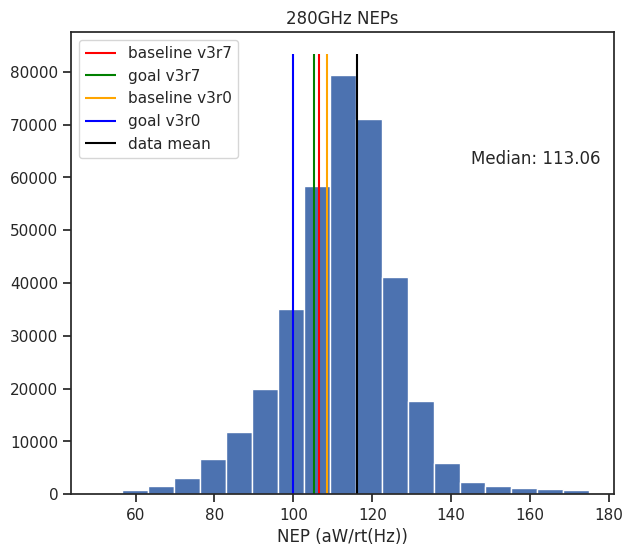

In [116]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(
    (np.char.find(nep_labels, "280") != -1)
    & (neps > 1e-6)
    & (1.1 < nep_df.pwv / np.sin(np.deg2rad(nep_df.el)))
    & (nep_df.pwv / np.sin(np.deg2rad(nep_df.el)) < 1.5)
)[0]

baseline_r0 = 108.63
baseline_r7 = 106.37

goal_r0 = 99.79
goal_r7 = 105.25

plt.hist(neps[flags] * 1e6, bins=np.linspace(50, 175, 20))
# plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(baseline_r7, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.vlines(np.nanmean(neps[flags] * 1e6), ymin, ymax, label="data mean", color="black")
plt.xlabel("NEP (aW/rt(Hz))")
plt.title("280GHz NEPs")
plt.legend()

plt.text(
    0.8 * xmin, 0.75 * ymin, "Median: {:.2f}".format(np.nanmedian(neps[flags] * 1e6))
)

f.savefig("./plts/neps/neps_280.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/neps/neps_280.png", dpi=600, bbox_inches="tight")

In [139]:
df_220 = nep_df[nep_df["labels"].str.contains("220")]
np.nanmedian(df_220.neps * df_220.abscals * 1e6 * 1 / np.sqrt(2))

np.float64(249.2326711241256)

In [140]:
df_220 = nep_df[nep_df["labels"].str.contains("280")]
np.nanmedian(df_220.neps * df_220.abscals * 1e6 * 1 / np.sqrt(2))

np.float64(417.8543819805584)

In [142]:
249.2326711241256 / np.sqrt(400)

np.float64(12.46163355620628)

In [143]:
417.8543819805584 / np.sqrt(700)

np.float64(15.79341112798781)

# NEPs vs PWV

In [19]:
np.arange(0, 4, 0.5)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5])

In [20]:
nep_df["pwv_sinel_bin"] = pd.cut(nep_df["pwv_sinel"], bins=np.arange(0, 4.5, 0.5))
nep_df["nepse6"] = nep_df["neps"] * 1e6

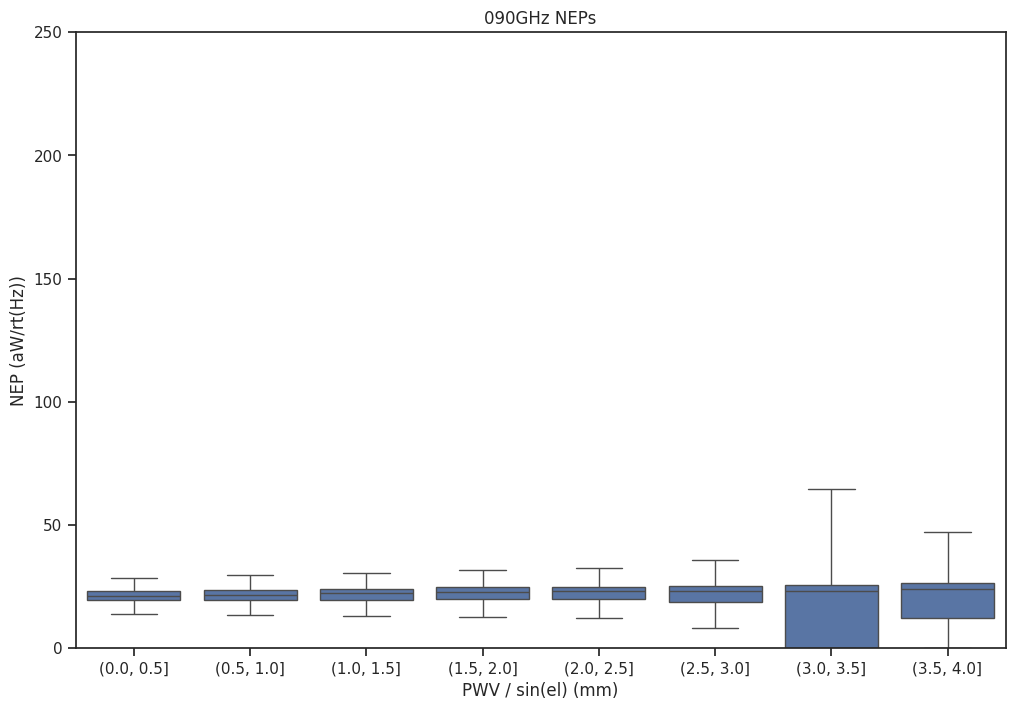

In [45]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("090")],
    x="pwv_sinel_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("090GHz NEPs")

plt.ylim(0, 250)
plt.savefig("./plts/neps/neps_pwvsinel_090.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_pwvsinel_090.pdf", dpi=600, bbox_inches="tight")

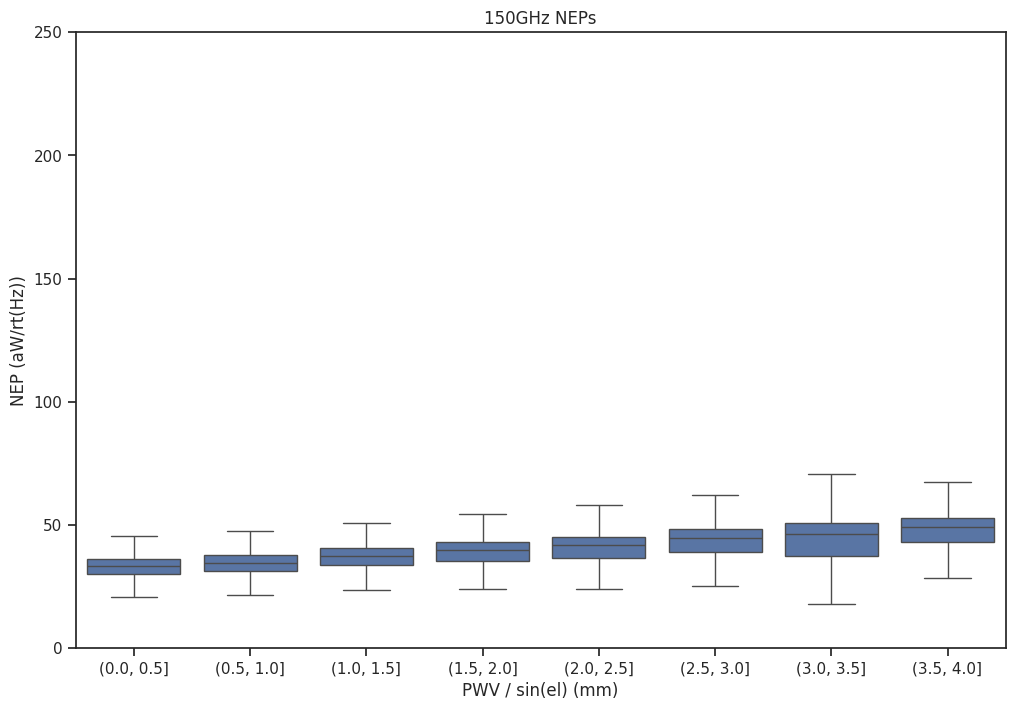

In [46]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("150")],
    x="pwv_sinel_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("150GHz NEPs")

plt.ylim(0, 250)
plt.savefig("./plts/neps/neps_pwvsinel_150.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_pwvsinel_150.pdf", dpi=600, bbox_inches="tight")

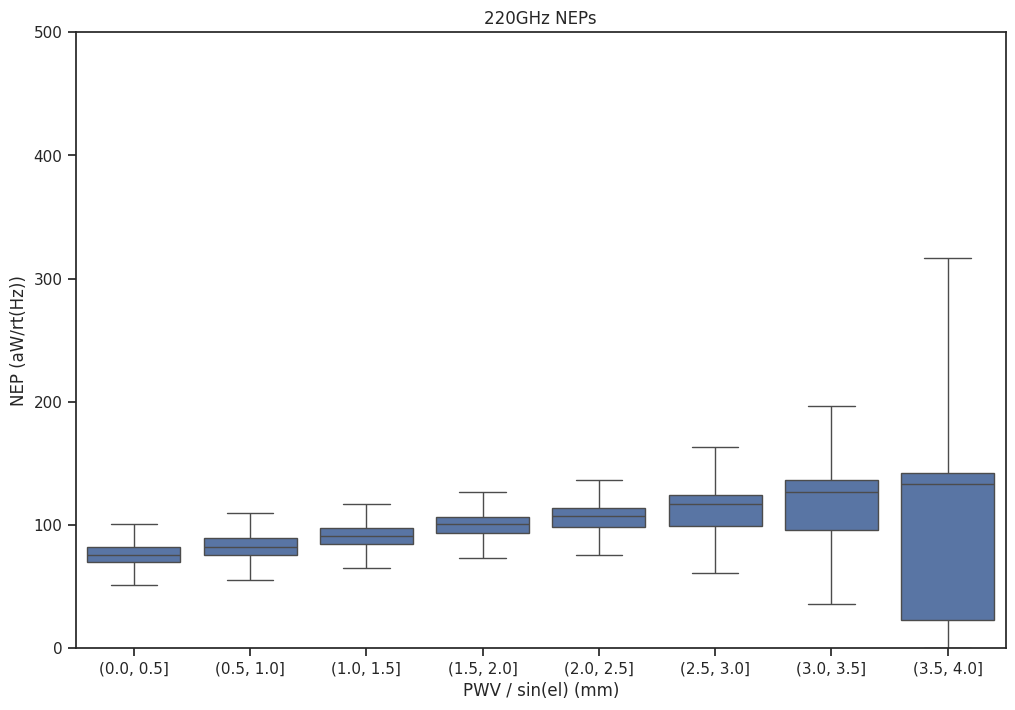

In [47]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("220")],
    x="pwv_sinel_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("220GHz NEPs")

plt.ylim(0, 500)
plt.savefig("./plts/neps/neps_pwvsinel_220.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_pwvsinel_220.pdf", dpi=600, bbox_inches="tight")

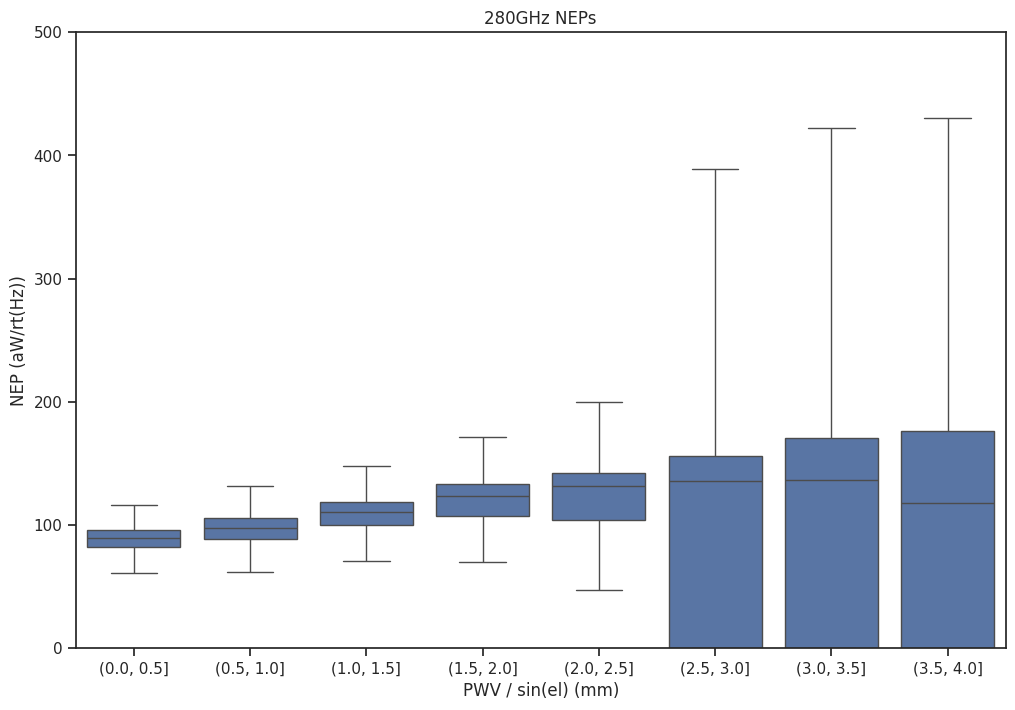

In [48]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("280")],
    x="pwv_sinel_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("PWV / sin(el) (mm)")
plt.title("280GHz NEPs")

plt.ylim(0, 500)
plt.savefig("./plts/neps/neps_pwvsinel_280.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_pwvsinel_280.pdf", dpi=600, bbox_inches="tight")

# NEP vs Lopt

In [77]:
fname = "lopt_fits.pk"

with open(fname, "rb") as f:
    lopt_dict = pk.load(f)

mv_ave = 0
i = 0

for key in lopt_dict.keys():
    if "mv" in key:
        popt = lopt_dict[key]["150"]["popt"]
        mv_ave += popt
        i += 1
mv_ave /= i


def lopt_func(x, L0, Lwet):
    return L0 + Lwet * x


def make_lopt(df):
    lopts = np.zeros(len(df))
    for i in range(len(df)):
        freq, label = df.labels[i].split("_")
        if (
            label == "mv49"
        ):  # No dark data for mv49, so use the average fit from f090 here
            popt = mv_ave
        else:
            popt = lopt_dict[label][freq]["popt"]
        lopts[i] = lopt_func(nep_df["pwv_sinel"][i], *popt)
    return lopts

In [97]:
nep_df["lopt"] = make_lopt(nep_df)
nep_df["lopt_bin"] = pd.cut(nep_df["lopt"], bins=np.arange(0, 30, 1))

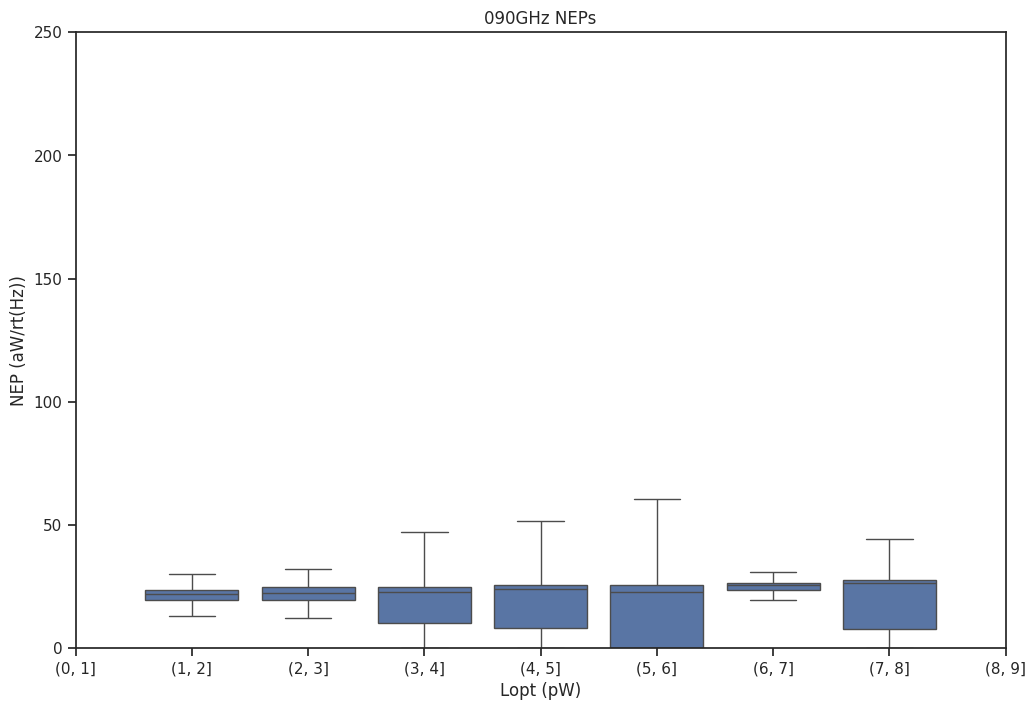

In [103]:
f, ax = plt.subplots(figsize=(12, 8))
fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("090")],
    x="lopt_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("Lopt (pW)")
plt.title("090GHz NEPs")

plt.ylim(0, 250)
plt.xlim(0, 8)
plt.savefig("./plts/neps/neps_lopt_090.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_lop_090.pdf", dpi=600, bbox_inches="tight")

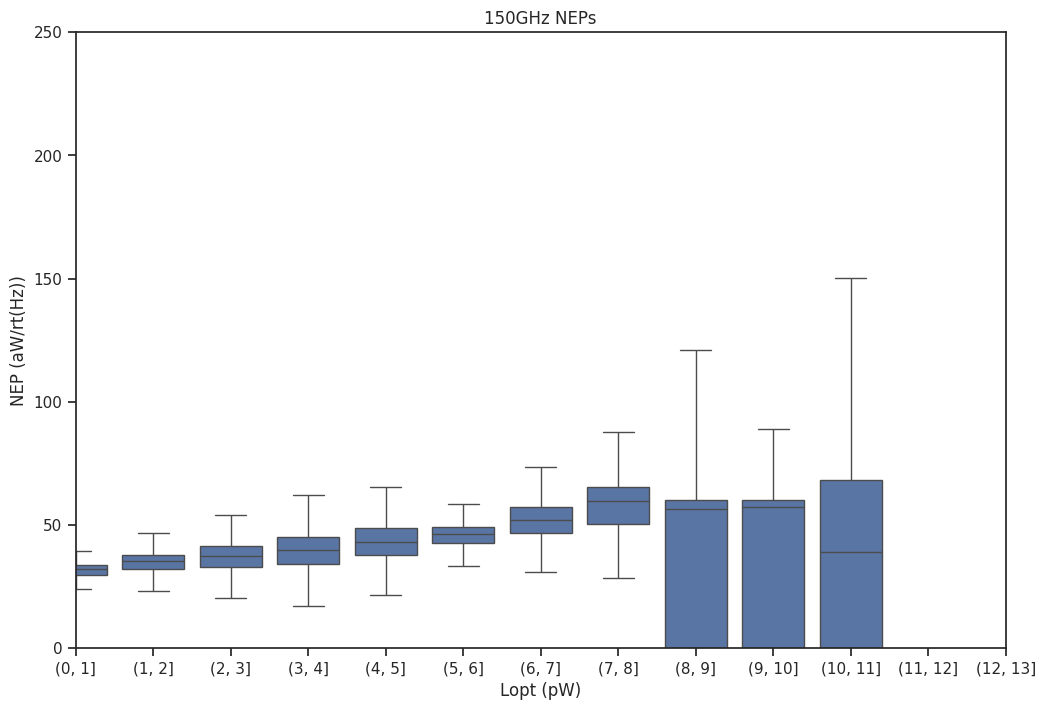

In [104]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("150")],
    x="lopt_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("Lopt (pW)")
plt.title("150GHz NEPs")

plt.ylim(0, 250)
plt.xlim(0, 12)
plt.savefig("./plts/neps/neps_lopt_150.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_lopt_150.pdf", dpi=600, bbox_inches="tight")

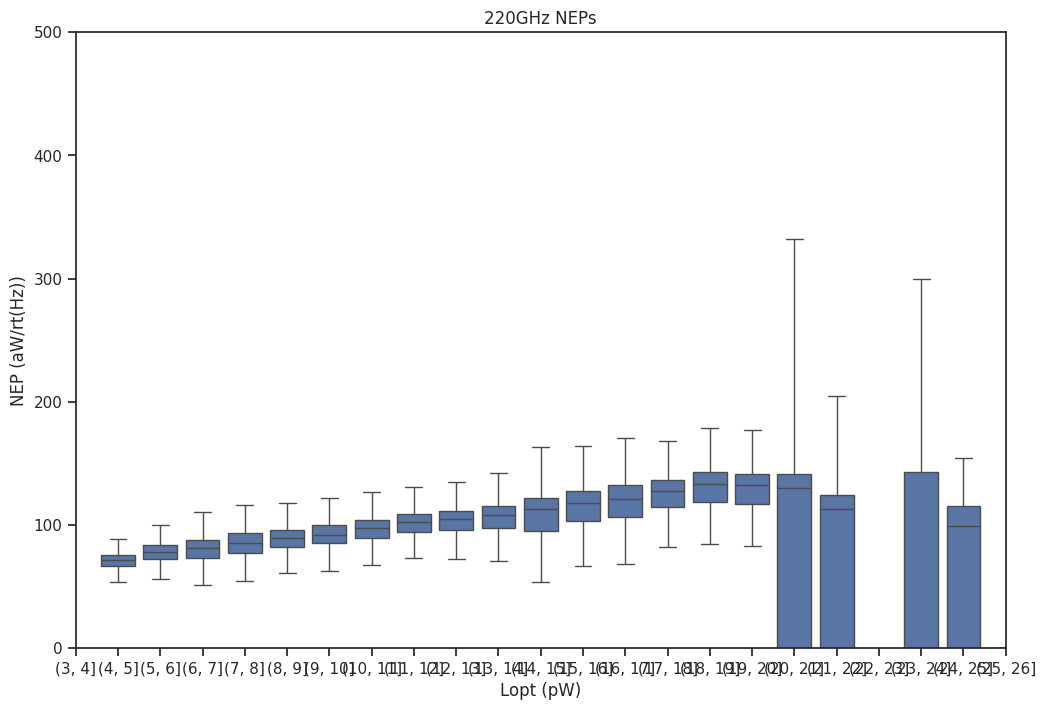

In [105]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("220")],
    x="lopt_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("Lopt (pW)")
plt.title("220GHz NEPs")

plt.ylim(0, 500)
plt.xlim(3, 25)
plt.savefig("./plts/neps/neps_lopt_220.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_lopt_220.pdf", dpi=600, bbox_inches="tight")

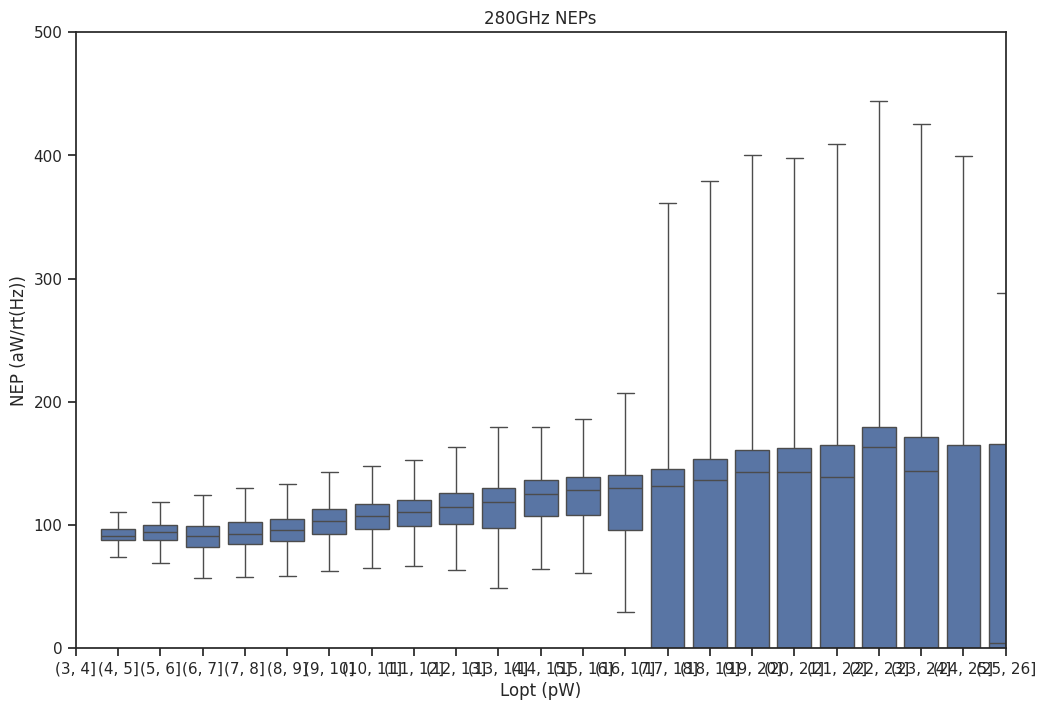

In [106]:
f, ax = plt.subplots(figsize=(12, 8))


fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.boxplot(
    data=nep_df[nep_df["labels"].str.contains("280")],
    x="lopt_bin",
    y="nepse6",
    showfliers=False,
)

plt.ylabel("NEP (aW/rt(Hz))")
plt.xlabel("Lopt (pW)")
plt.title("280GHz NEPs")

plt.ylim(0, 500)
plt.xlim(3, 25)
plt.savefig("./plts/neps/neps_lopt_280.png", dpi=600, bbox_inches="tight")
plt.savefig("./plts/neps/neps_lopt_280.pdf", dpi=600, bbox_inches="tight")